<a href="https://colab.research.google.com/github/Oktazz/pasien-covid/blob/main/pasien_covid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Prediksi kematian pada pasien Covid-19

###mengumpulkan data

In [ ]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Menghubungkan dengan gdrive

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Baca dataset

pasien_dataset = pd.read_csv('/content/drive/MyDrive/Colab-Notebooks/dataset/pasienCovid/CovidData.csv')

# ambil beberapa data saja, karena ada 1jt data di dalam dataset tersebut
pasien = pasien_dataset.sample(n=6000, random_state=42)

###menelaah data

In [ ]:
# ubah kolom DATE_DIED ke data biner
pasien['DIED'] = np.where(pasien['DATE_DIED'] == '9999-99-99', 0, 1)

# karena sudah tidak digunakan,
# hapus kolom DATE_DIED
pasien = pasien.drop(columns=['DATE_DIED'])

In [ ]:


# ubah kolom ke biner (1, 2) ke 0, 1
binary_cols = ['PNEUMONIA', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR', 'HIPERTENSION',
               'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC',
               'TOBACCO', 'INTUBED', 'ICU']

for col in binary_cols:
  pasien[col] = pasien[col].replace({1: 1, 2: 0, 97: 0, 98: 0, 99: 0})

pasien['PATIENT_TYPE'] = pasien['PATIENT_TYPE'].replace({1: 0, 2: 1})

# ubah semua data kolom ke bentuk binary
# ubah sex awal = 1: Female, 2:Male
#          ubah = 0: Female, 1:Male
pasien['SEX'] = pasien['SEX'].replace({1: 0, 2: 1})

# tangani PREGNANT pada laki-laki
pasien.loc[pasien['SEX'] == 1, 'PREGNANT'] = 2
pasien['PREGNANT'] = pasien['PREGNANT'].replace({1: 1, 2: 0, 97: 0, 98: 0, 99: 0})

melihat 5 baris pertama
        USMER  MEDICAL_UNIT  SEX  PATIENT_TYPE  INTUBED  PNEUMONIA  AGE  \
781974      2            12    0             0        0          0   35   
937737      2            12    1             0        0          0   28   
907828      2            12    0             0        0          0    7   
784628      2            12    0             0        0          0   35   
662460      2            12    0             0        0          0   33   

        PREGNANT  DIABETES  COPD  ...  INMSUPR  HIPERTENSION  OTHER_DISEASE  \
781974         0         0     0  ...        0             0              0   
937737         0         0     0  ...        0             1              0   
907828         0         0     0  ...        0             0              0   
784628         0         1     0  ...        0             0              0   
662460         0         0     0  ...        0             0              0   

        CARDIOVASCULAR  OBESITY  RENAL_CHRONIC  TO

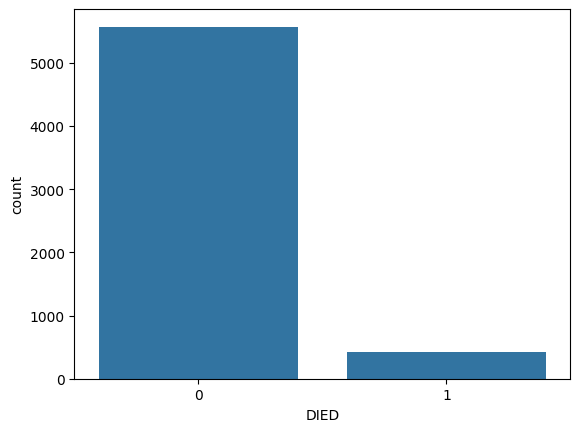

In [ ]:
# tampilkan 5 baris pertama
print('melihat 5 baris pertama')
print(pasien.head())

# melihat informasi umum dataset
print('melihat informasi umum dataset')
print(pasien.info())

#statistik descriptif
print('statistik deskriptif')
print(pasien.describe())

print('distribusi tiap kolom kategorikal')
print(pasien['DIED'].value_counts())

# visual
print('visual')
sns.countplot(x='DIED', data=pasien)
plt.show()


###validasi data

In [ ]:
# cek data duplikat
print('cek data duplikat')
print('Jumlah duplikat: ', pasien.duplicated().sum())

# cek range nilai numerik AGE
print('cek range nilai numerik AGE')
numeric_cols = ['AGE', 'MEDICAL_UNIT', 'CLASIFFICATION_FINAL']
print(pasien[numeric_cols].describe())

# cek missing value
print('cek missing value')
print(pasien.isnull().sum())

cek data duplikat
Jumlah duplikat:  1890
cek range nilai numerik AGE
             AGE  MEDICAL_UNIT  CLASIFFICATION_FINAL
count  6000.0000   6000.000000           6000.000000
mean     42.0640      8.946167              5.331000
std      16.9463      3.731209              1.879901
min       0.0000      3.000000              1.000000
25%      30.0000      4.000000              3.000000
50%      41.0000     12.000000              6.000000
75%      53.0000     12.000000              7.000000
max     100.0000     13.000000              7.000000
cek missing value
USMER                   0
MEDICAL_UNIT            0
SEX                     0
PATIENT_TYPE            0
INTUBED                 0
PNEUMONIA               0
AGE                     0
PREGNANT                0
DIABETES                0
COPD                    0
ASTHMA                  0
INMSUPR                 0
HIPERTENSION            0
OTHER_DISEASE           0
CARDIOVASCULAR          0
OBESITY                 0
RENAL_CHRONIC       

###menentukan objek data

In [ ]:
from sklearn.model_selection import train_test_split

# target (y) dan fitur (x)
X = pasien.drop(columns=['DIED'])
y = pasien['DIED']

print('Fitur (X): ', X.columns)
print('Target (y): ', y.name)

Fitur (X):  Index(['USMER', 'MEDICAL_UNIT', 'SEX', 'PATIENT_TYPE', 'INTUBED', 'PNEUMONIA',
       'AGE', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR',
       'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY',
       'RENAL_CHRONIC', 'TOBACCO', 'CLASIFFICATION_FINAL', 'ICU'],
      dtype='object')
Target (y):  DIED


###membersihkan data

In [ ]:
# hapus data duplikat
pasien = pasien.drop_duplicates()
print('Jumlah duplikat setelah dihapus: ', pasien.duplicated().sum())



Jumlah duplikat setelah dihapus:  0


### mengkonstruksi data

X_train:  (4200, 20)
X_test:  (1800, 20)
[[ 0.76713902  0.81600528 -0.98816526 ... -0.29726228  0.89371119
  -0.12828453]
 [ 0.76713902  0.81600528  1.01197647 ... -0.29726228 -1.23176276
  -0.12828453]
 [ 0.76713902 -1.33053644  1.01197647 ... -0.29726228 -1.23176276
  -0.12828453]
 ...
 [ 0.76713902 -1.33053644 -0.98816526 ... -0.29726228 -1.23176276
  -0.12828453]
 [ 0.76713902  0.81600528 -0.98816526 ... -0.29726228  0.89371119
  -0.12828453]
 [-1.3035447  -0.79390101 -0.98816526 ... -0.29726228  0.89371119
  -0.12828453]]
Shape X_train (4200, 20)
Shape X_test (1800, 20)


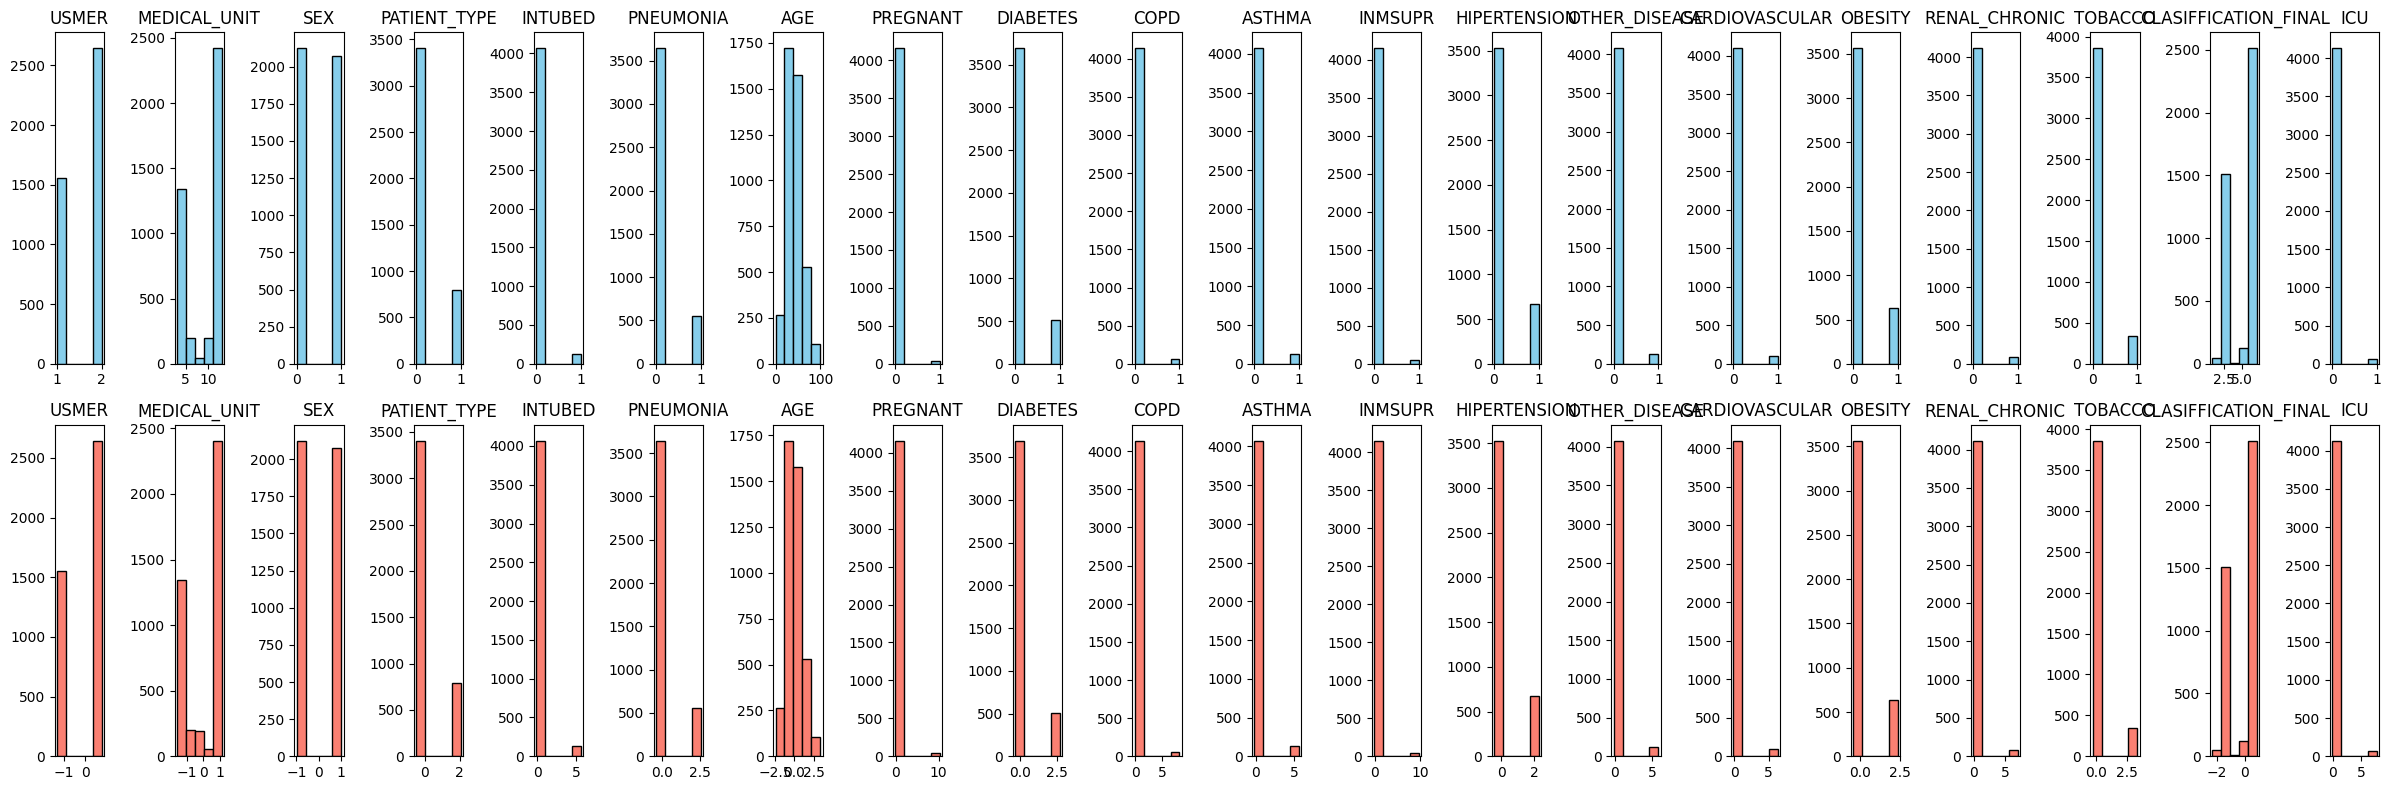

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# split data train dan test
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.3, random_state=42
)
print('X_train: ', X_train.shape)
print('X_test: ', X_test.shape)

# normalisasi fitur numerik
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled)

print('Shape X_train', X_train_scaled.shape)
print('Shape X_test', X_test_scaled.shape)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# --- Plot Histogram sebelum dan sesudah ---
fig, axes = plt.subplots(2, len(X_train.columns), figsize=(24, 8))

for i, col in enumerate(X_train.columns):
  #sebelum normalisasi
  axes[0, i].hist(X_train[col], bins=5, color='skyblue', edgecolor='black')
  axes[0, i].set_title(col)

  #sesudah normalisasi
  axes[1, i].hist(X_train_scaled_df[col], bins=5, color='salmon', edgecolor='black')
  axes[1, i].set_title(col)

plt.tight_layout()
plt.show()

### Mengatasi Imbalanced Data dengan SMOTE

In [ ]:
# Instal library imblearn jika belum terinstal
!pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

# Sebelum SMOTE
print('Jumlah sampel y_train sebelum SMOTE:')
print(y_train.value_counts())

# Terapkan SMOTE hanya pada data pelatihan
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Setelah SMOTE
print('\nJumlah sampel y_train setelah SMOTE:')
print(y_train_resampled.value_counts())

# Perbarui variabel X_train dan y_train dengan versi yang sudah di-resample
X_train = X_train_resampled
y_train = y_train_resampled

print('\nShape X_train setelah SMOTE:', X_train_resampled.shape)
print('Shape y_train setelah SMOTE:', y_train_resampled.shape)

Jumlah sampel y_train sebelum SMOTE:
DIED
0    3907
1     293
Name: count, dtype: int64

Jumlah sampel y_train setelah SMOTE:
DIED
0    3907
1    3907
Name: count, dtype: int64

Shape X_train setelah SMOTE: (7814, 20)
Shape y_train setelah SMOTE: (7814,)


Shape X_train_scaled setelah SMOTE dan normalisasi: (7814, 20)
Shape X_test_scaled setelah SMOTE dan normalisasi: (1800, 20)


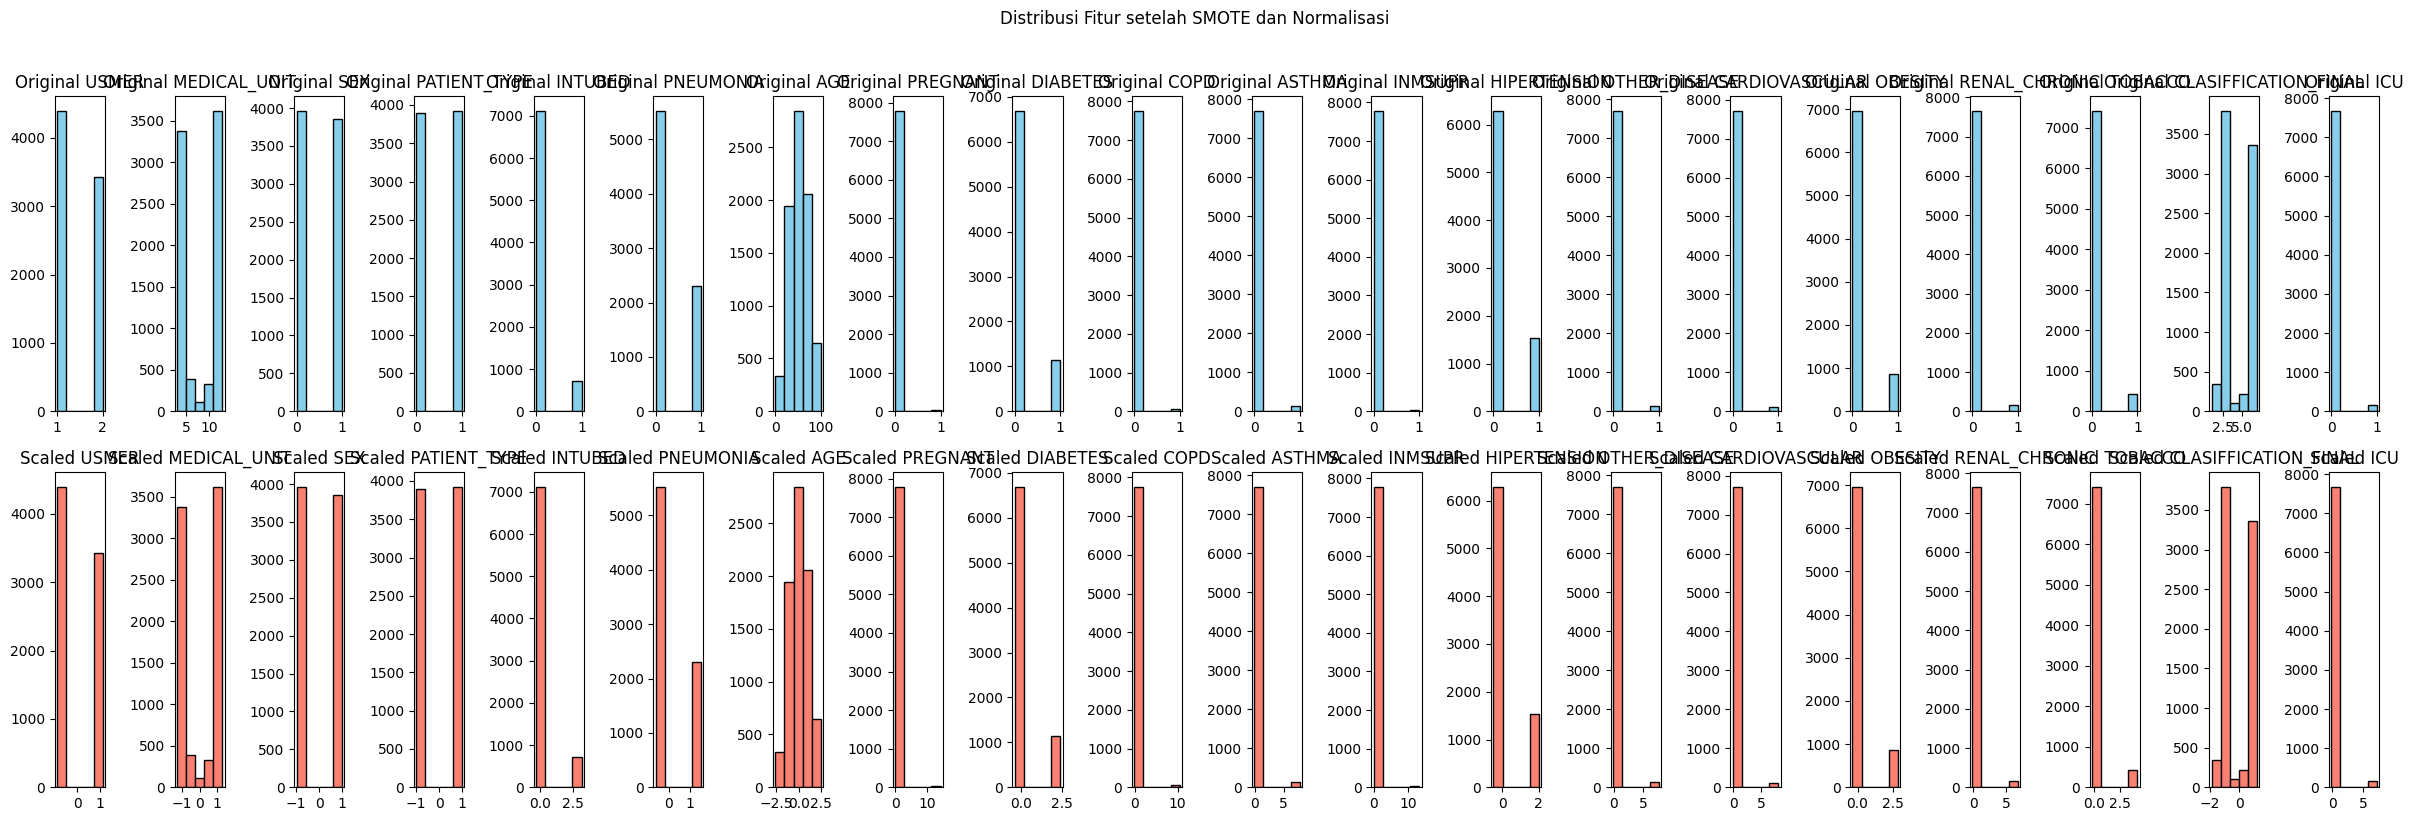

In [ ]:
# Normalisasi fitur numerik pada data X_train yang sudah di-resample
# Perlu diingat bahwa scaler harus di-fit ulang ke data training yang sudah di-resample
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Shape X_train_scaled setelah SMOTE dan normalisasi:', X_train_scaled.shape)
print('Shape X_test_scaled setelah SMOTE dan normalisasi:', X_test_scaled.shape)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# --- Plot Histogram setelah SMOTE dan Normalisasi ---
fig, axes = plt.subplots(2, len(X_train.columns), figsize=(24, 8))
fig.suptitle('Distribusi Fitur setelah SMOTE dan Normalisasi', y=1.02)

for i, col in enumerate(X_train.columns):
  # sebelum normalisasi
  axes[0, i].hist(X_train[col], bins=5, color='skyblue', edgecolor='black')
  axes[0, i].set_title(f'Original {col}')

  # sesudah normalisasi
  axes[1, i].hist(X_train_scaled_df[col], bins=5, color='salmon', edgecolor='black')
  axes[1, i].set_title(f'Scaled {col}')

plt.tight_layout()
plt.show()

###Menghitung korelasi antar fitur dengan target

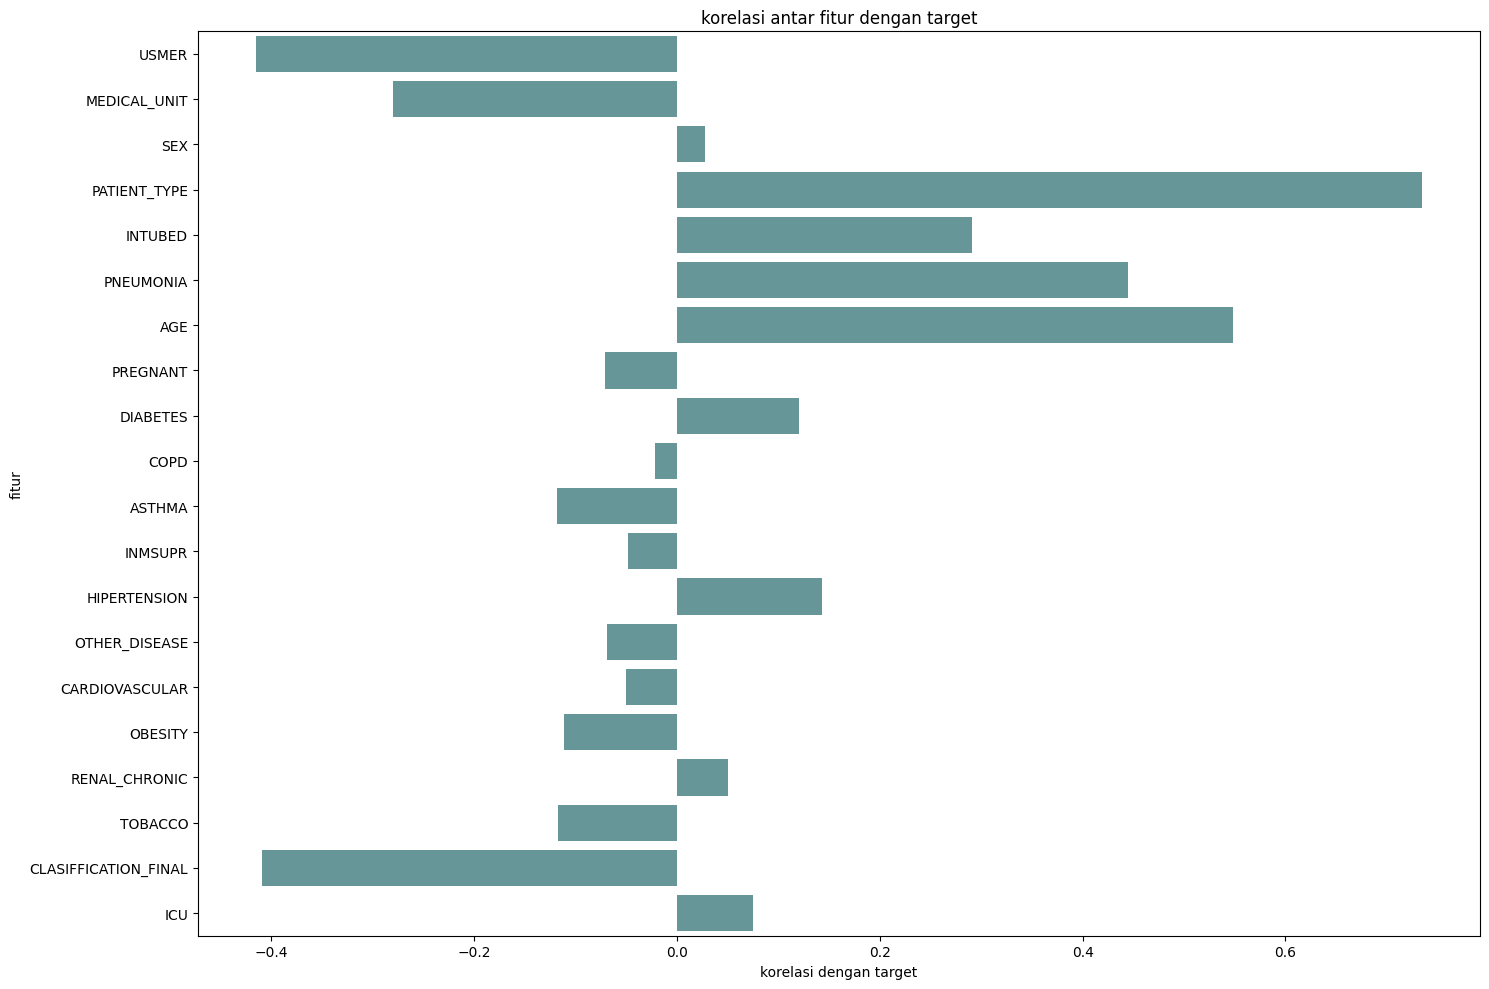

In [ ]:
# Pastikan X_train_for_corr memiliki index yang sama dengan y_train
X_train_for_corr = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

# Buat Series untuk target agar bisa digabung dengan fitur
y_train_series_for_corr = pd.Series(y_train, name='Target', index=X_train.index)

# Gabungkan fitur dan target menjadi satu DataFrame untuk menghitung korelasi
combined_df = pd.concat([X_train_for_corr, y_train_series_for_corr], axis=1)

# Hitung korelasi dari combined_df dan ambil kolom 'Target'
corr_with_deposit = combined_df.corr()['Target'].drop('Target') # Drop self-correlation

# Dapatkan nama fitur untuk plotting
features = corr_with_deposit.index.tolist()

# Buat viualisasi bar plot
fig, ax = plt.subplots(figsize=(15,10), tight_layout=True)
sns.barplot(x=corr_with_deposit.values, y=features, color='cadetblue')
plt.xlabel('korelasi dengan target')
plt.ylabel('fitur')
plt.title('korelasi antar fitur dengan target')
plt.show()


###Membangun Model

In [ ]:
# Import algoritma Logistic Regression
from sklearn.linear_model import  LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Model Logictic Regression
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

# Prediksi
y_pred_lr = model.predict(X_test_scaled)
print('Prediksi: ', y_pred_lr[:5])
print('Label Asli: ', y_test[:5].values)
print('Accuracy: ', accuracy_score(y_test, y_pred_lr))

Prediksi:  [0 0 0 0 0]
Label Asli:  [0 0 0 0 0]
Accuracy:  0.8983333333333333


In [ ]:
# Import algoritma RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled) # Corrected: should use X_test_scaled
print('Prediksi: ', y_pred_rf[:5])
print('Label Asli: ', y_test[:5].values)
print('Accuracy: ', accuracy_score(y_test, y_pred_rf))

Prediksi:  [0 0 0 0 0]
Label Asli:  [0 0 0 0 0]
Accuracy:  0.9177777777777778


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Model Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=3)
clf.fit(X_train_scaled, y_train)
y_pred_dt = clf.predict(X_test_scaled)
print('Prediksi: ', y_pred_dt[:5])
print('Label Asli: ', y_test[:5].values)
print('Accuracy: ', accuracy_score(y_test, y_pred_dt))

Prediksi:  [0 0 0 0 0]
Label Asli:  [0 0 0 0 0]
Accuracy:  0.8811111111111111


In [ ]:
# # Import algoritma KNN
# from sklearn.neighbors import KNeighborsClassifier

# # Model KNN
# knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
# knn.fit(X_train_scaled, y_train)
# y_pred_knn = knn.predict(X_test)
# print('Prediksi: ', y_pred[:5])
# print('Label Asli: ', y_test[:5].values)
# print('Accuracy: ', accuracy_score(y_test, y_pred))

###Evaluasi Model

Evaluasi Model Logistic Regression
Classification Report: 
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      1663
           1       0.41      0.81      0.55       137

    accuracy                           0.90      1800
   macro avg       0.70      0.86      0.75      1800
weighted avg       0.94      0.90      0.91      1800

Confusion Matrix: 


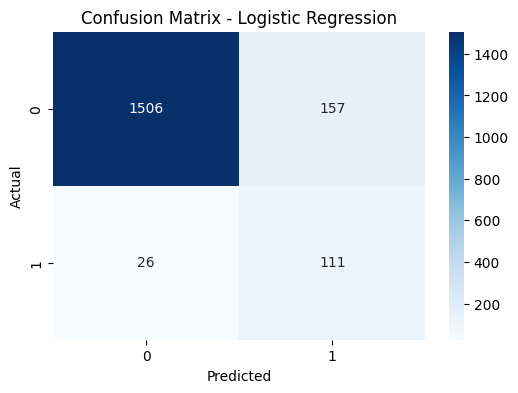

Evaluasi Model Random Forest Classifier
Classification Report: 
              precision    recall  f1-score   support

           0       0.97      0.94      0.95      1663
           1       0.47      0.65      0.55       137

    accuracy                           0.92      1800
   macro avg       0.72      0.79      0.75      1800
weighted avg       0.93      0.92      0.92      1800

Confusion Matrix: 


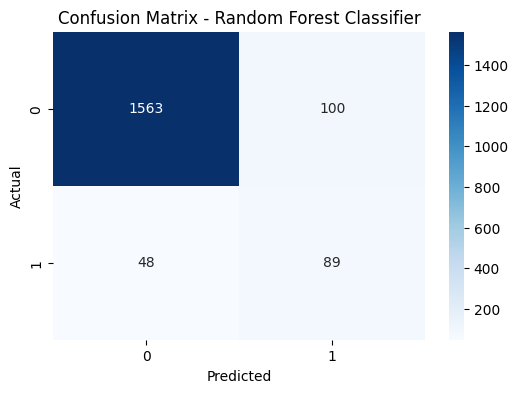

Evaluasi Model DT
Classification Report: 
              precision    recall  f1-score   support

           0       0.98      0.89      0.93      1663
           1       0.37      0.82      0.51       137

    accuracy                           0.88      1800
   macro avg       0.68      0.86      0.72      1800
weighted avg       0.94      0.88      0.90      1800

Confusion Matrix: 


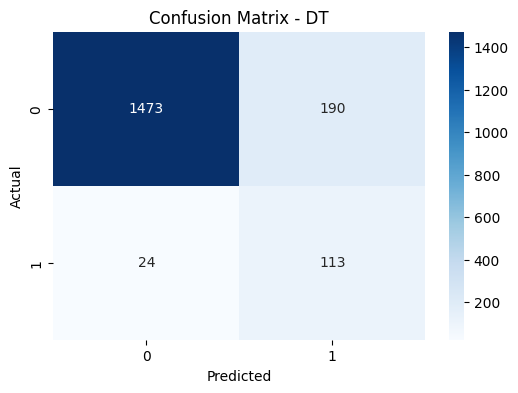

In [ ]:
# Evaluasi Model Logistic Regression
print('Evaluasi Model Logistic Regression')
print('Classification Report: ')
print(classification_report(y_test, y_pred_lr,))

print('Confusion Matrix: ')
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# Evaluasi Model RandomForestClassifier
print('Evaluasi Model Random Forest Classifier')
print('Classification Report: ')
print(classification_report(y_test, y_pred_rf))

print('Confusion Matrix: ')
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.show()

# Evaluasi Model KNN
print('Evaluasi Model DT')
print('Classification Report: ')
print(classification_report(y_test, y_pred_dt))

print('Confusion Matrix: ')
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - DT')
plt.show()

###Menyimpan Model

In [ ]:
import joblib

joblib.dump(clf, 'model_decision_tree')
joblib.dump(rf, 'model_random_forest')
joblib.dump(model, 'model_logistic_regression')


print('model berhasil di simpan')

model berhasil di simpan


### Menyimpan Scaler

Untuk konsistensi dalam preprocessing data baru, `StandardScaler` yang telah di-fit pada data pelatihan juga perlu disimpan.

In [ ]:
import joblib

# Simpan scaler
joblib.dump(scaler, 'standard_scaler.pkl')

print('Scaler berhasil disimpan sebagai standard_scaler.pkl')

Scaler berhasil disimpan sebagai standard_scaler.pkl


### Memuat Kembali Scaler

Untuk menggunakannya kembali, Anda bisa memuatnya seperti ini:

In [ ]:
# Muat kembali scaler yang sudah disimpan
loaded_scaler = joblib.load('standard_scaler.pkl')

print('Scaler berhasil dimuat:', loaded_scaler)

# Anda bisa menggunakannya untuk menransformasi data baru
# new_data_scaled = loaded_scaler.transform(new_data_unscaled)

Scaler berhasil dimuat: StandardScaler()


### Simulasi Penggunaan Model pada Data Baru

Untuk memprediksi data baru, kita harus memuat model dan menerapkan transformasi yang sama (preprocessing) yang kita lakukan pada data asli.

In [ ]:
# 1. Muat Model yang sudah disimpan
loaded_model = joblib.load('model_random_forest')

# 2. Siapkan data baru (contoh data mentah)
data_baru_mentah = pd.DataFrame({
    'USMER': [2],
    'MEDICAL_UNIT': [4],
    'SEX': [2],
    'PATIENT_TYPE': [1],
    'INTUBED': [98],
    'PNEUMONIA': [2],
    'AGE': [58],
    'PREGNANT': [97],
    'DIABETES': [2],
    'COPD': [2],
    'ASTHMA': [2],
    'INMSUPR': [2],
    'HIPERTENSION': [2],
    'OTHER_DISEASE': [2],
    'CARDIOVASCULAR': [2],
    'OBESITY': [2],
    'RENAL_CHRONIC': [2],
    'TOBACCO': [2],
    'CLASIFFICATION_FINAL': [3],
    'ICU': [98]
})

# 3. Langkah Preprocessing (Wajib Sama dengan sebelumnya)
# Mapping biner 1, 2 menjadi 1, 0
binary_cols = ['PNEUMONIA', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR', 'HIPERTENSION',
               'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC',
               'TOBACCO', 'INTUBED', 'ICU']

for col in binary_cols:
    data_baru_mentah[col] = data_baru_mentah[col].replace({1: 1, 2: 0, 97: 0, 98: 0, 99: 0})

data_baru_mentah['PATIENT_TYPE'] = data_baru_mentah['PATIENT_TYPE'].replace({1: 0, 2: 1})
data_baru_mentah['SEX'] = data_baru_mentah['SEX'].replace({1: 0, 2: 1})
data_baru_mentah['PREGNANT'] = data_baru_mentah['PREGNANT'].replace({1: 1, 2: 0, 97: 0, 98: 0, 99: 0})

# 4. Scaling menggunakan scaler yang sudah dimuat (loaded_scaler)
data_baru_scaled = loaded_scaler.transform(data_baru_mentah)

# 5. Prediksi
hasil_prediksi = loaded_model.predict(data_baru_scaled)

print(hasil_prediksi)

status = "Meninggal" if hasil_prediksi[0] == 1 else "Sembuh/Hidup"
print(f'Hasil Prediksi: {status}')

[0]
Hasil Prediksi: Sembuh/Hidup
